# 04. Part-to-Whole Analysis: Understanding Proportional Contribution
### Primary Analytical Purpose: *How does each part contribute to the total?*

---

## 1. Learning Objectives

By completing this notebook, you will be able to:
- **Evaluate Proportions**: Quantify how individual segments combine to form an entire business portfolio (100% total).
- **Compare Composition Visuals**: Build **stacked bar charts** in Seaborn, and both **pie/donut charts** and **treemaps** in Plotly Express.
- **Understand Perceptual Strengths & Limitations**: Articulate why **Treemaps** and **Stacked Bars** often outperform traditional **Pie Charts**.
- **Analyze Portfolio Balance**: Diagnose over-dependence on a single revenue stream and formulate diversification strategies.

**The Analytical Workflow:**
$$\text{Business Question} \longrightarrow \text{Analyze Data} \longrightarrow \text{Visualize Patterns} \longrightarrow \text{Interpret Visuals} \longrightarrow \text{Actionable Insight}$$


## 2. Business Scenario

**Company:** *CloudCommerce Inc.* — an enterprise technology and software provider.  
**Context:** CloudCommerce generates revenue across five core business divisions: **Cloud Infrastructure**, **Enterprise Software**, **Consumer Hardware**, **Consulting & Implementation**, and **Digital Subscriptions**.

The Chief Financial Officer (CFO) is presenting the annual revenue composition to the Board of Directors. The Board wants to see the proportional breakdown of total company revenue ($120 Million), evaluate portfolio diversification, and understand which business unit carries the greatest operational weight.


In [11]:
# Standard imports for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn visual theme
sns.set_theme(style="whitegrid")


## 3. Dataset Creation

We generate a clean, mutually exclusive dataset where all divisions sum exactly to the company's total annual revenue of **$120,000,000**.
We also calculate each category's exact percentage share of the whole.


In [12]:
# Define divisions and revenue ($)
data = [
    {"category": "Cloud Infrastructure",        "revenue": 48000000},
    {"category": "Enterprise Software",         "revenue": 32000000},
    {"category": "Consumer Hardware",           "revenue": 18000000},
    {"category": "Consulting & Implementation",  "revenue": 12000000},
    {"category": "Digital Subscriptions",       "revenue": 10000000},
]

df = pd.DataFrame(data)

# Compute percentage share of total revenue
total_revenue = df["revenue"].sum()
df["pct_share"] = (df["revenue"] / total_revenue) * 100

print(f"Dataset created: {len(df)} business units. Total Revenue = ${total_revenue:,.0f}")


Dataset created: 5 business units. Total Revenue = $120,000,000


## 4. Dataset Preview

Always verify that individual components sum to the expected total before building part-to-whole charts.


In [13]:
# Display dataset with percentage shares
df


,category,revenue,pct_share
0,Cloud Infrastructure,48000000,40.000000
1,Enterprise Software,32000000,26.666667
2,Consumer Hardware,18000000,15.000000
3,Consulting & Implementation,12000000,10.000000
4,Digital Subscriptions,10000000,8.333333


In [14]:
# Check column types and confirm 100% sum
print(f"Sum of revenue: ${df['revenue'].sum():,.0f}")
print(f"Sum of percentage shares: {df['pct_share'].sum():.1f}%")


Sum of revenue: $120,000,000
Sum of percentage shares: 100.0%


## 5. Analytical Questions

As an analyst examining portfolio composition, you must answer:
1. **Dominant Contributor:** Which single business category contributes the largest share of overall company revenue?
2. **Proportional Distribution:** What exact percentage of total revenue does each division represent?
3. **Portfolio Concentration:** Do the top two divisions represent a majority of total revenue?


## 6. Seaborn Visualization (100% Stacked Bar Chart)

A **stacked bar chart** represents 100% of a total as a single unified bar divided into colored segments. 
This format is widely considered by data visualization experts to be significantly easier to read than a pie chart because the human visual cortex excels at comparing linear lengths along a straight axis.


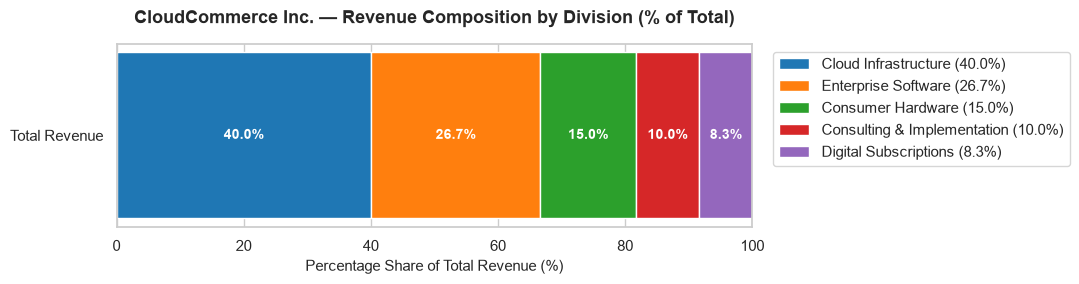

In [15]:
# Create a 100% stacked horizontal bar chart in Seaborn/Matplotlib
plt.figure(figsize=(11, 3))

# Palette of distinct harmonious colors
colors = sns.color_palette("tab10", len(df))

# Compute left positions for cumulative horizontal stacking
left_pos = 0
for i, row in df.iterrows():
    width = row["pct_share"]
    plt.barh(y="Total Revenue", width=width, left=left_pos, color=colors[i], 
             label=f"{row['category']} ({width:.1f}%)", edgecolor="white", height=0.5)
    
    # Label inside segments if wide enough
    if width > 7:
        plt.text(left_pos + width / 2, 0, f"{width:.1f}%", 
                 ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    left_pos += width

plt.title("CloudCommerce Inc. — Revenue Composition by Division (% of Total)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Percentage Share of Total Revenue (%)", fontsize=11)
plt.xlim(0, 100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


## 7. Plotly Express Visualizations (Donut Chart & Treemap)

Plotly Express provides modern interactive alternatives for composition analysis:
1. **Donut Chart (`px.pie` with `hole` parameter):** Slices represent proportions; the central cutout improves scannability compared to traditional solid pies.
2. **Treemap (`px.treemap`):** Employs nested rectangles whose areas are proportional to revenue, making area comparisons intuitive and scalable.


In [16]:
# Visualization 1: Modern Interactive Donut Chart
fig_donut = px.pie(
    df,
    names="category",
    values="revenue",
    hole=0.35, # Modern donut cutout
    title="<b>Revenue Contribution by Division (Donut Chart)</b>",
    labels={"revenue": "Revenue ($)", "category": "Division"}
)

fig_donut.update_traces(
    textposition="inside",
    textinfo="percent+label",
    hovertemplate="<b>%{label}</b><br>Revenue: $%{value:,.0f}<br>Share: %{percent:.1%}<extra></extra>"
)
fig_donut.update_layout(template="plotly_white")
fig_donut.show()


In [17]:
# Visualization 2: Interactive Treemap
fig_tree = px.treemap(
    df,
    path=["category"],
    values="revenue",
    color="revenue",
    color_continuous_scale="Mint",
    title="<b>Revenue Contribution Treemap</b>",
    labels={"revenue": "Annual Revenue ($)"}
)

fig_tree.update_traces(
    hovertemplate="<b>%{label}</b><br>Revenue: $%{value:,.0f}<extra></extra>"
)
fig_tree.update_layout(template="plotly_white")
fig_tree.show()


## 8. Interpretation

Let us interpret what these part-to-whole visualizations communicate:

1. **The Lead Contributor:**
   - **Cloud Infrastructure** is the single largest division, delivering **$48,000,000**, which represents exactly **40.0%** of total revenue.
   - **Enterprise Software** is the second largest at **$32,000,000**, accounting for **26.7%** of the whole.

2. **Top-Heavy Portfolio Concentration:**
   - Together, Cloud Infrastructure (40%) and Enterprise Software (26.7%) constitute **66.7% (two-thirds)** of all corporate revenue.
   - CloudCommerce is essentially a B2B cloud and software company with secondary ancillary offerings.

3. **Supporting Segments:**
   - Consumer Hardware contributes 15.0% ($18M), Consulting represents 10.0% ($12M), and Digital Subscriptions accounts for 8.3% ($10M).


## 9. Key Insights, Treemaps vs. Pie Charts & Best Practices

### What Happened?
- Two-thirds of company revenue is tied directly to enterprise IT infrastructure and software contracts.

### Actionable Business Recommendations:
1. **Protect Enterprise Renewal Rates:**
   - Given that 66.7% of cash flow relies on Cloud Infrastructure and Enterprise Software, customer success teams should be focused heavily on net revenue retention (NRR) and multi-year renewals for top enterprise clients.
2. **Cross-Sell Subscriptions into Hardware:**
   - Consumer Hardware (15%) has lower recurring predictability than SaaS. Offer bundled Digital Subscriptions (8.3%) with hardware purchases to convert one-off hardware buyers into recurring subscription subscribers.

---

### In-Depth Discussion: Treemaps vs. Pie Charts

| Feature | Pie / Donut Charts | Treemaps | Stacked Bar Charts |
| :--- | :--- | :--- | :--- |
| **Perceptual Channel** | Angles & Arc Lengths (difficult for eyes) | 2D Rectangular Area (moderate accuracy) | Linear Length along aligned scale (most accurate) |
| **Max Recommended Categories** | 3 to 5 slices max | Dozens of categories easily | 3 to 6 segments |
| **Handling Small Slices** | Cluttered, overlapping labels | Clearly visible small boxes | Thin stripes |
| **Hierarchies** | Terrible (requires multi-ring sunbursts) | Outstanding (nested boxes) | Good (facets or side-by-side bars) |

#### Limitations of Pie Charts:
1. **Angle Perception:** Human eyes struggle to judge angles. If two slices represent 21% and 18%, human viewers cannot tell which is larger without reading the numbers.
2. **Label Clutter:** When a pie chart exceeds 5 or 6 slices, labels overlap or require cumbersome callout leader lines.
3. **Zero / Negative Values:** Pie charts cannot display zero or negative numbers.

#### Advantages of Treemaps:
1. **Space Efficient:** Treemaps utilize 100% of the rectangular screen space without wasted margins.
2. **Scalability:** Treemaps can easily display 20+ categories without label collisions.
3. **Hierarchical Drill-Down:** Treemaps can represent nested groups (e.g. Division $\rightarrow$ Product Line $\rightarrow$ SKU).

---

### Common Analytical Mistake to Avoid:
> **Mistake: Using Part-to-Whole Charts When Parts Do Not Sum to 100%**  
> Never use a pie chart, donut chart, or treemap to display survey questions where respondents could "Select All That Apply", or metrics that are not parts of a single unified total (such as comparing average salaries across countries). Part-to-whole charts require **mutually exclusive segments that add up to a true 100% whole**.


## 10. Practice Exercises

### Exercise 1: Chart Interpretation
Looking at the visualizations:
1. What percentage share does *Consumer Hardware* represent in the company portfolio?
2. Which category contributes the smallest percentage to total revenue?
3. How much total revenue do the bottom two divisions (*Consulting* and *Subscriptions*) contribute combined?


### Exercise 2: Modify Chart Settings (Custom Donut Chart)
In the code cell below, modify the Plotly donut chart:
- Change the donut cutout size to `hole=0.55`.
- Use a custom qualitative color sequence: `color_discrete_sequence=px.colors.qualitative.Prism`.
- Pull/explode the largest slice slightly (`pull=[0.08, 0, 0, 0, 0]`) to emphasize the leading division.


In [18]:
# Exercise 2: Student Code
fig_custom_donut = px.pie(
    df,
    names="category",
    values="revenue",
    hole=0.55,
    color_discrete_sequence=px.colors.qualitative.Prism,
    title="<b>Executive Portfolio Share (Emphasizing Top Contributor)</b>"
)

# Explode the first slice (Cloud Infrastructure)
fig_custom_donut.update_traces(
    pull=[0.08, 0, 0, 0, 0],
    textinfo="percent+label",
    textposition="outside"
)
fig_custom_donut.update_layout(template="plotly_white")
fig_custom_donut.show()


### Exercise 3: Answer a Business Question (Scenario Simulation)
Suppose **Enterprise Software** experiences a **25% revenue surge** next year due to an AI product rollout, while all other divisions remain flat.
Calculate:
1. The new revenue for Enterprise Software.
2. The new total company revenue.
3. The new percentage share of Enterprise Software.


In [19]:
# Exercise 3: Student Code
# Scenario calculations
old_software_rev = df.loc[df["category"] == "Enterprise Software", "revenue"].values[0]
new_software_rev = old_software_rev * 1.25

other_rev = df.loc[df["category"] != "Enterprise Software", "revenue"].sum()
new_total_rev = other_rev + new_software_rev
new_software_share = (new_software_rev / new_total_rev) * 100

print(f"Original Enterprise Software Revenue: ${old_software_rev:,.0f} ({df.loc[df['category']=='Enterprise Software', 'pct_share'].values[0]:.1f}%)")
print(f"Simulated Enterprise Software Revenue: ${new_software_rev:,.0f}")
print(f"New Total Corporate Revenue: ${new_total_rev:,.0f}")
print(f"New Enterprise Software Share: {new_software_share:.1f}%")


Original Enterprise Software Revenue: $32,000,000 (26.7%)
Simulated Enterprise Software Revenue: $40,000,000
New Total Corporate Revenue: $128,000,000
New Enterprise Software Share: 31.2%


## 11. Challenge Activity

**Hierarchical Composition with Nested Treemaps:**  
Business divisions are often composed of smaller sub-departments.

1. Review the hierarchical DataFrame provided in the cell below (Division $\rightarrow$ Product Line).
2. Create an interactive hierarchical Plotly Treemap using `path=["division", "product_line"]`.
3. Hover through the levels and write two analytical insights regarding which specific product lines carry each division.


In [20]:
# Challenge Activity: Hierarchical Treemap
hierarchical_data = [
    {"division": "Cloud Infrastructure", "product_line": "Compute Clusters", "revenue": 30000000},
    {"division": "Cloud Infrastructure", "product_line": "Storage & Backups", "revenue": 18000000},
    {"division": "Enterprise Software",  "product_line": "ERP Core",         "revenue": 20000000},
    {"division": "Enterprise Software",  "product_line": "CRM Cloud",        "revenue": 12000000},
    {"division": "Consumer Hardware",    "product_line": "Smart Displays",   "revenue": 11000000},
    {"division": "Consumer Hardware",    "product_line": "Audio Accessories","revenue": 7000000},
    {"division": "Consulting & Support", "product_line": "Cloud Migration",  "revenue": 8000000},
    {"division": "Consulting & Support", "product_line": "24/7 SLA Support",  "revenue": 4000000},
    {"division": "Digital Subscriptions","product_line": "Pro User Seats",   "revenue": 10000000},
]
hdf = pd.DataFrame(hierarchical_data)

fig_hier = px.treemap(
    hdf,
    path=["division", "product_line"],
    values="revenue",
    color="division",
    title="<b>Hierarchical Revenue Contribution (Division & Product Line)</b>"
)
fig_hier.update_layout(template="plotly_white")
fig_hier.show()


## 12. Key Takeaways

- **Must Equal 100%:** Part-to-whole charts are only valid when the segments represent a closed, exhaustive set of mutually exclusive parts that sum to a meaningful total.
- **Limit Pie Slices:** Restrict pie/donut charts to 3 to 5 categories max. If you have more than 5 categories, use a **Treemap** or a **Bar Chart**.
- **Treemaps for Complex Portfolios:** Treemaps excel at showing large numbers of categories and hierarchical parent-child relationships in a compact rectangular footprint.
- **Stacked Bars for Comparing Portfolios:** When comparing part-to-whole compositions across multiple years or regions, 100% stacked bar charts are dramatically superior to multiple pie charts.
